# Assignment: Trees

## Do two questions in total: "Q1+Q2" or "Q1+Q3"

`! git clone https://github.com/ds3001f25/linear_models_assignment.git`

**Q1.** Please answer the following questions in your own words.
1. Why is the Gini a good loss function for categorical target variables? 
- The Gini impurity measueres how often a randomly chosen observation would be incorecctly classified if it were randomly labeled according to the distrubtion of labels in the set. It's a good loss function for categorical target variables because it gives the "purity" score of a node, meaning how mixed the classes are in that node. A lower Gini impurity indicates a better split, which helps in creating decision trees that effectively separate different classes.
2. Why do trees tend to overfit, and how can this tendency be constrained? 
- Trees tend to overfit because they often split until nodes are pure, which captures noise and specific patterns in the training data that do not generalize well to unseen data. This can be constrained by techniques such as imposing a limit on the depth of the tree, imposing a lower bound on the impurity score of a terminal node, and imposing a limit on how few cases a terminal node can have.
3. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates. 
- False. Trees can perform well with both categorical and continuous variables. For example, trees can work well for numeric regression tasks. They work well here because they can split the continuous variable into ranges that best separate the target variable.
4. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?
- Most versions of classification/regression trees allow for only two branches after a split because binary splits simplify the tree structure and make it easier to interpret. You only need to consider two outcomes at each node, which reduces complexity and helps in managing overfitting.
5. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?
- Some signs of overfitting include a very deep tree with many nodes, high accuracy on training data but low accuracy on validation/test data, and very small terminal nodes. Signs of underfitting include a very shallow tree that does not capture the complexity of the data, low accuracy on both training and validation/test data, and large terminal nodes.

**Q2.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy? 

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q3.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$. 

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?
- The model is decent at predicting the different bond ratings, with an accuracy score of about 0.68. The confusion matrix shows that the model performs better on type B and C ratings, while getting A ratings incorrect roughly 50% of the time. This suggests that the model may be better at identifying lower-rated bonds, while struggling with higher-rated ones.

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?
- Including the rating agency as a feature improves the model's accuracy to about 0.76. This indicates that the rating agency itself carries significant information about the bond ratings, possibly due to differing evaluation criteria or biases among agencies.

Number of observations: 2029
Number of variables: 31


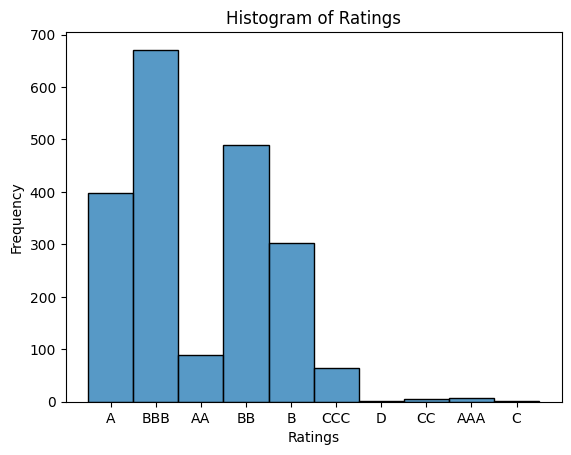

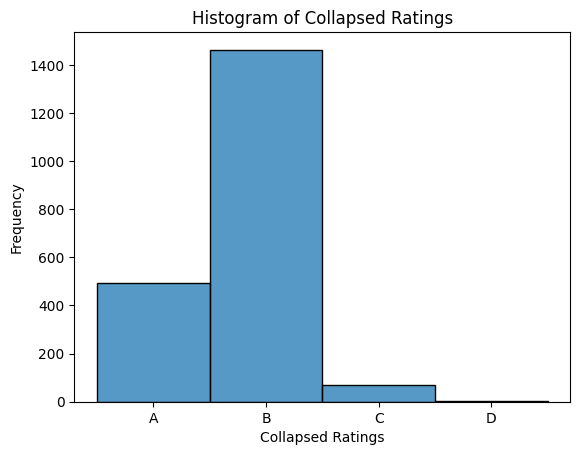

Accuracy: 0.6823
Confusion Matrix:
Predicted   A    B  C
Actual               
A          47   49  0
B          59  227  8
C           1   11  3
D           1    0  0
Accuracy with Rating Agency Name: 0.7562
Confusion Matrix with Rating Agency Name:
Predicted   A    B  C
Actual               
A          54   42  0
B          34  253  7
C           0   15  0
D           0    1  0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

#Q1
df = pd.read_csv('./data/corporate_ratings.csv')
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

df.head()

#Q2
sns.histplot(df['Rating'], bins=20, kde=False)
plt.title('Histogram of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

def collapse_ratings(rating):
    if rating in ['AAA', 'AA', 'A']:
        return 'A'
    elif rating in ['BBB', 'BB', 'B']:
        return 'B'
    elif rating in ['CCC', 'CC', 'C']:
        return 'C'
    else:
        return rating
df['collapsed_ratings'] = df['Rating'].apply(collapse_ratings)
sns.histplot(df['collapsed_ratings'], bins=20, kde=False)
plt.title('Histogram of Collapsed Ratings')
plt.xlabel('Collapsed Ratings')
plt.ylabel('Frequency')
plt.show()

#Q3 Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$. 
X = df.drop(columns=['Rating', 'collapsed_ratings', 'Symbol', 'Date', 'Name', 'Rating Agency Name'])
X = pd.get_dummies(X, columns=['Sector'], drop_first=True)

#Q4 Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?
y = df['collapsed_ratings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cart = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
cart.fit(X_train, y_train)
y_pred = cart.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
confusion_mtx = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_mtx)

#Q5
X2 = df.drop(columns=['Rating', 'collapsed_ratings', 'Symbol', 'Date', 'Name'])
X2 = pd.get_dummies(X2, columns=['Sector', 'Rating Agency Name'], drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
cart2 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
cart2.fit(X2_train, y2_train)
y2_pred = cart2.predict(X2_test)
accuracy2 = accuracy_score(y2_test, y2_pred)
print(f"Accuracy with Rating Agency Name: {accuracy2:.4f}")
confusion_mtx2 = pd.crosstab(y2_test, y2_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix with Rating Agency Name:")
print(confusion_mtx2)



